In [1]:
%%time
# =========================
# 0) Setup e imports - Competencia Data Mining UBA 2025
# =========================
!pip -q install polars==1.7.1 sympy matplotlib seaborn google-cloud-storage

import polars as pl
from pathlib import Path
from types import SimpleNamespace
import json, numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import optuna
from sympy import primerange
from google.cloud import storage

# Seeds oficiales de la competencia
SEEDS = [509963, 739373, 794341, 900623, 917827,
        946331, 682049, 415963, 163847, 846247,
        288203, 227407, 164513, 402299, 257437,
        789631, 812963, 361033, 698983, 827063,
        803591, 938053, 212791, 263759, 740023,
        426997, 507139, 185833, 929749, 412967,
        159473, 282571, 423853, 716707, 267133,
        895901, 115153, 173137, 228251, 568433,
        628937, 131591, 813961, 216421, 361327,
        759673, 105871, 484853, 239783, 724949,
]

# Paths definitivos en Google Cloud / repo git
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent
SCHEMA_PATH = NOTEBOOK_DIR / "schema.json"
BASE_DIR    = NOTEBOOK_DIR / "dmeyf2025"

BUCKET_NAME = "nicocaviglia031_bukito3"
BUCKET_LOCAL_DIR = PROJECT_ROOT / BUCKET_NAME
BUCKET_LOCAL_DIR.mkdir(parents=True, exist_ok=True)


CPU times: user 5.42 s, sys: 946 ms, total: 6.37 s
Wall time: 22 s


In [2]:
# CSV_PATH    = PROJECT_ROOT / "datasets" / "competencia_02_crudo.csv"
# CSV_PATH2    = PROJECT_ROOT / "datasets" / "competencia_03_crudo.csv"
FINAL_PATH = PROJECT_ROOT / "datasets" / "competencia_03.csv"

# df1 = pd.read_csv(CSV_PATH)
# df2 = pd.read_csv(CSV_PATH2)
# df = pd.concat([df1, df2], ignore_index = True)
# df.to_csv(FINAL_PATH)


In [3]:
%%time
# =========================
# 1) Lectura de DF con Schema
# =========================

# Cargar schema
with open(SCHEMA_PATH) as f:
    schema_dict = json.load(f)

# Convertir strings a dtypes de Polars
schema = {k: getattr(pl, v) for k, v in schema_dict.items()}

# Lectura estricta (sin inferir tipos)
df = pl.read_csv(FINAL_PATH, schema_overrides=schema)
df = df.rechunk()  # Compactar memoria

# drop_cols = ["mprestamos_personales", "cprestamos_personales"]
# df = df.drop(drop_cols)

first_col = df.columns[0]
df = df.drop(first_col)

df.shape

CPU times: user 36.7 s, sys: 15.7 s, total: 52.5 s
Wall time: 45.1 s


(4883051, 154)

In [4]:
# =========================
# 1.1) Canaritos + Setup de zLGBM
# =========================

def create_canaritos(df: pl.DataFrame, qcanaritos: int = 5) -> pl.DataFrame:
    """
    Añade un número específico de columnas "canarito" (features aleatorias)
    a un DataFrame de Polars.

    Estas nuevas columnas contendrán valores aleatorios uniformes (entre 0 y 1)
    y se colocarán al principio del DataFrame, manteniendo el orden
    original de las demás columnas.

    Args:
        df (pl.DataFrame): El DataFrame de Polars al que se le añadirán
                           las columnas.
        qcanaritos (int): El número de columnas "canarito" que se
                            desea crear (ej: 5).

    Returns:
        pl.DataFrame: Un nuevo DataFrame con las columnas "canarito" añadidas
                      al principio.
    """

    # 1. Guardar los nombres de las columnas originales
    original_cols = df.columns
    num_filas = df.height
    # 2. Generar la lista de nombres para las nuevas columnas "canarito"
    canary_cols = [f"canarito_{i}" for i in range(1, qcanaritos + 1)]

    # 3. Crear las expresiones Polars para generar los números aleatorios
    #    pl.rand_uniform(0, 1) es el equivalente a runif()
    canary_expressions = [pl.lit(np.random.rand(num_filas)).alias(name) for name in canary_cols]

    # 4. Añadir las nuevas columnas y reordenar todo en un solo paso
    #    Usamos .select() para el reordenamiento final
    df = df.with_columns(
        canary_expressions
    ).select(
        canary_cols + original_cols  # Concatena listas para el nuevo orden
    )

    return df

In [5]:
%%time
# =========================
# 2) Construcción de clase_ternaria (baseline del profesor)
# =========================

def agregar_clase_ternaria_optimizada(df: pl.DataFrame) -> pl.DataFrame:
    """
    Versión optimizada usando Polars - Baseline del profesor
    """
    return (
        df.lazy()
        .sort(["numero_de_cliente", "foto_mes"])
        .with_columns([
            pl.when(
                pl.col("foto_mes").shift(-1).over("numero_de_cliente").is_null() &
                (pl.col("foto_mes") != pl.col("foto_mes").max())
            ).then(pl.lit("BAJA+1"))
            .when(
                pl.col("foto_mes").shift(-2).over("numero_de_cliente").is_null() &
                (pl.col("foto_mes") <= pl.col("foto_mes").max() - 2)
            ).then(pl.lit("BAJA+2"))
            .otherwise(pl.lit("CONTINUA"))
            .alias("clase_ternaria")
        ])
        .collect()
    )

# Agregar la columna clase_ternaria
df = agregar_clase_ternaria_optimizada(df)

# Tabla de frecuencia de clase_ternaria por foto_mes
tabla_clases = (
    df.pivot(
        values="numero_de_cliente",
        index="foto_mes",
        on="clase_ternaria",
        aggregate_function="len"
    )
    .fill_null(0)
)

print(tabla_clases)

shape: (33, 4)
┌──────────┬──────────┬────────┬────────┐
│ foto_mes ┆ CONTINUA ┆ BAJA+2 ┆ BAJA+1 │
│ ---      ┆ ---      ┆ ---    ┆ ---    │
│ i64      ┆ u32      ┆ u32    ┆ u32    │
╞══════════╪══════════╪════════╪════════╡
│ 201901   ┆ 122920   ┆ 720    ┆ 633    │
│ 201902   ┆ 123985   ┆ 694    ┆ 722    │
│ 201903   ┆ 124535   ┆ 738    ┆ 694    │
│ 201904   ┆ 125294   ┆ 501    ┆ 743    │
│ 201905   ┆ 126016   ┆ 682    ┆ 504    │
│ …        ┆ …        ┆ …      ┆ …      │
│ 202105   ┆ 161948   ┆ 841    ┆ 1128   │
│ 202106   ┆ 162339   ┆ 1133   ┆ 841    │
│ 202107   ┆ 162211   ┆ 1250   ┆ 1135   │
│ 202108   ┆ 163570   ┆ 0      ┆ 1252   │
│ 202109   ┆ 165093   ┆ 0      ┆ 0      │
└──────────┴──────────┴────────┴────────┘
CPU times: user 10.1 s, sys: 6.28 s, total: 16.4 s
Wall time: 3.79 s


In [6]:
# =========================
# Feature engineering: agregados de montos/contadores
# =========================

# Totales de saldos en pesos
SALDOS_PESOS = [
    "mcuenta_corriente",
    "mcaja_ahorro",
    "mcuenta_corriente_adicional",
    "mcaja_ahorro_adicional",
    "mcuentas_saldo",
]

# Consumo tarjetas pesos
CONSUMO_TARJETAS_PESOS = [
    "mtarjeta_visa_consumo",
    "mtarjeta_master_consumo",
]

# Consumo tarjetas dólares
CONSUMO_TARJETAS_DOLARES = [
    "Visa_mconsumosdolares",
    "Master_mconsumosdolares",
]

# Pagos recurrentes pesos
PAGOS_RECURRENTE_PESOS = [
    "mpagodeservicios",
    "mpagomiscuentas",
    "mcuenta_debitos_automaticos",
    "mttarjeta_visa_debitos_automaticos",
    "mttarjeta_master_debitos_automaticos",
]

# Sumas de productos de inversión y plazos fijos pesos
INVERSIONES_PESOS = [
    "mplazo_fijo_pesos",
    "minversion1_pesos",
    "minversion2",
]

# Sumas de productos de inversión y plazos fijos dólares
INVERSIONES_DOLARES = [
    "mplazo_fijo_dolares",
    "minversion1_dolares",
]

# Endeudamiento total pesos
ENDEUDAMIENTO_PESOS = [
    "mprestamos_prendarios",
    "mprestamos_hipotecarios",
    "Master_msaldopesos",
    "Visa_msaldopesos",
    "Master_madelantopesos",
    "Visa_madelantopesos",
]

# Endeudamiento total dólares
ENDEUDAMIENTO_DOLARES = [
    "Master_msaldodolares",
    "Visa_msaldodolares",
    "Master_madelantodolares",
    "Visa_madelantodolares",
]

# Ingresos payroll pesos
PAYROLL_PESOS = [
    "mpayroll",
    "mpayroll2",
]

# Límites de compra
LIMITES_COMPRA = [
    "Master_mlimitecompra",
    "Visa_mlimitecompra",
]

# Suma de seguros contratados
SEGUROS_COUNT = [
    "cseguro_vida",
    "cseguro_auto",
    "cseguro_vivienda",
    "cseguro_accidentes_personales",
]

# Totales de transacciones (conteo)
TRANSACCIONES_COUNT = [
    "ctarjeta_debito_transacciones",
    "ctarjeta_visa_transacciones",
    "ctarjeta_master_transacciones",
    "chomebanking_transacciones",
    "cmobile_app_trx",
    "ccallcenter_transacciones",
    "catm_trx",
    "catm_trx_other",
    "ccajas_transacciones",
]

def sum_columns_safe(df: pl.DataFrame, cols: list[str]) -> pl.Series:
    existentes = [c for c in cols if c in df.columns]
    if not existentes:
        return pl.lit(0)
    return pl.sum_horizontal([pl.col(c) for c in existentes])

fe_columns = {
    "m_saldo_total_pesos": SALDOS_PESOS,
    "m_consumo_tarjetas_pesos": CONSUMO_TARJETAS_PESOS,
    "m_consumo_tarjetas_dolares": CONSUMO_TARJETAS_DOLARES,
    "m_pagos_recurrentes_pesos": PAGOS_RECURRENTE_PESOS,
    "m_inversiones_pesos": INVERSIONES_PESOS,
    "m_inversiones_dolares": INVERSIONES_DOLARES,
    "m_endeudamiento_pesos": ENDEUDAMIENTO_PESOS,
    "m_endeudamiento_dolares": ENDEUDAMIENTO_DOLARES,
    "m_payroll_total": PAYROLL_PESOS,
    "m_limite_compra_total": LIMITES_COMPRA,
    "c_seguros_total": SEGUROS_COUNT,
    "c_transacciones_total": TRANSACCIONES_COUNT,
}

df = df.with_columns([
    sum_columns_safe(df, cols).alias(col_name)
    for col_name, cols in fe_columns.items()
])

df.shape

(4883051, 167)

In [7]:
%%time
# =========================
# 4) Feature Engineering Histórico - Lags y DeltaLags
# =========================

# Excluir IDs y metadata
EXCLUDE = {"numero_de_cliente", "foto_mes", "clase_ternaria"}

# Identificar columnas numéricas
num_cols = [c for c, dt in zip(df.columns, df.dtypes)
            if c not in EXCLUDE and dt.is_numeric()]

def add_lags_and_deltas(df: pl.DataFrame, cols: list[str]) -> pl.DataFrame:
    """
    Agregar lags y deltas de orden 1 y 2 - Baseline del profesor
    """
    out = df.sort(["numero_de_cliente", "foto_mes"]).lazy()

    # Lags 1 y 2
    out = out.with_columns([
        pl.col(c).shift(1).over("numero_de_cliente").alias(f"{c}_lag1") for c in cols
    ] + [
        pl.col(c).shift(2).over("numero_de_cliente").alias(f"{c}_lag2") for c in cols
    ])

    # Delta 1: x_t - x_{t-1} ; Delta 2: x_t - x_{t-2}
    out = out.with_columns([
        (pl.col(c) - pl.col(f"{c}_lag1")).alias(f"{c}_d1") for c in cols
    ] + [
        (pl.col(c) - pl.col(f"{c}_lag2")).alias(f"{c}_d2") for c in cols
    ])

    return out.collect()

# Aplicar lags y deltas
df = add_lags_and_deltas(df, num_cols)

df.shape

CPU times: user 2min 14s, sys: 40.6 s, total: 2min 55s
Wall time: 2min 30s


(4883051, 823)

In [8]:
# =========================
# 4.1) Creacion de Canaritos
# =========================

plocal = SimpleNamespace(
    qcanaritos=5,
    min_data_in_leaf=20,
    learning_rate=1.0,
    gradient_bound=0.1,
    APO=5,
    ksemillerio=1,
)

df = create_canaritos(df, plocal.qcanaritos)

In [9]:
# Configuración de la competencia
TRAIN_MESES = [
    201901, 201902, 201903, #201904, 
    201905, 201906, 201907, 201908, 
    201909, 201910, 201911, 201912, 
    202001, 202002, 202003, 202004, 202005, #202006, 
    202007, 202008, 202009, #202010, 
    202011, 202012, 202101, 202102,
    202103, 202104, 202105
]

TEST_MES   = 202107
TEST_MES2   = 202107

APPLY_MES = 202107


In [10]:
%%time
# =========================
# 5) Undersampling de todos los registros CONTINUA al 3%
# =========================

train_subset = df.filter(pl.col("foto_mes").is_in(TRAIN_MESES))

# Separar registros por clase
registros_continua = train_subset.filter(pl.col("clase_ternaria") == "CONTINUA")
registros_baja = train_subset.filter(pl.col("clase_ternaria").is_in(["BAJA+1", "BAJA+2"]))

# Hacer undersampling del 3% de todos los registros CONTINUA
fraccion_sample = 0.03
n_total_continua = registros_continua.height
n_sample = max(1, int(np.ceil(n_total_continua * fraccion_sample)))

registros_continua_sample = registros_continua.sample(n=n_sample, seed=SEEDS[0])

# Combinar registros CONTINUA muestreados con todos los BAJA
_df_train = pl.concat([registros_continua_sample, registros_baja])
_df_test = df.filter(pl.col("foto_mes") == TEST_MES)
_df_apply = df.filter(pl.col("foto_mes") == APPLY_MES)

CPU times: user 40.3 s, sys: 50.1 s, total: 1min 30s
Wall time: 11.6 s


In [11]:
# =========================
# 5.1) Validación de la data
# =========================

print("_df_train shape:", _df_train.shape)
print("_df_test shape:", _df_test.shape)
print("_df_apply shape:", _df_apply.shape)
print("Primeras columnas en df      :", df.columns[:10])
print("Primeras columnas en _df_train:", _df_train.columns[:10])

_df_train shape: (145744, 828)
_df_test shape: (164596, 828)
_df_apply shape: (164596, 828)
Primeras columnas en df      : ['canarito_1', 'canarito_2', 'canarito_3', 'canarito_4', 'canarito_5', 'numero_de_cliente', 'foto_mes', 'active_quarter', 'cliente_vip', 'internet']
Primeras columnas en _df_train: ['canarito_1', 'canarito_2', 'canarito_3', 'canarito_4', 'canarito_5', 'numero_de_cliente', 'foto_mes', 'active_quarter', 'cliente_vip', 'internet']


In [ ]:
%%time
# =========================
# 6) Entrenamiento LightGBM con métrica de ganancia (semillero)
# =========================

plocal = SimpleNamespace(
    qcanaritos=5,
    min_data_in_leaf=20,
    learning_rate=1.0,
    gradient_bound=0.1,
    APO=5,
    ksemillerio=1,   
)

PARAM = SimpleNamespace(
    semilla_primigenia=SEEDS[0],  
    qcanaritos=plocal.qcanaritos,
)

# Constantes de ganancia
GANANCIA_ACIERTO = 780000
COSTO_ESTIMULO = 20000

def calcular_ganancias_acumuladas(y_true, y_pred_proba):
    """Calcula la ganancia acumulada ordenando por probabilidad descendente."""
    df_eval = pl.DataFrame({"y_true": y_true, "y_pred_proba": y_pred_proba})
    df_ordenado = df_eval.sort("y_pred_proba", descending=True)
    df_ordenado = df_ordenado.with_columns(
        pl.when(pl.col("y_true") == 1)
        .then(GANANCIA_ACIERTO)
        .otherwise(-COSTO_ESTIMULO)
        .alias("ganancia_individual")
    )
    df_ordenado = df_ordenado.with_columns(
        pl.col("ganancia_individual").cast(pl.Int64).cum_sum().alias("ganancia_acumulada")
    )
    return df_ordenado["ganancia_acumulada"].to_numpy()

# Convertir a pandas
train_pd = _df_train.to_pandas()
test_pd = _df_test.to_pandas()
apply_pd = _df_apply.to_pandas()  # si lo necesitas después

drop_cols = {"numero_de_cliente", "foto_mes", "clase_ternaria"}
feature_cols = [c for c in train_pd.columns if c not in drop_cols]

print("=== Dataset shapes ===")
print(f"train: {train_pd.shape} | test: {test_pd.shape}")
print(f"Features disponibles: {len(feature_cols)} (incluye canaritos={plocal.qcanaritos})")

# Targets y pesos
y_train = train_pd["clase_ternaria"].isin(["BAJA+1", "BAJA+2"]).astype(int)

weight_train = np.where(y_train == 1, 1.00002, 1.0)

lgb_train = lgb.Dataset(train_pd[feature_cols], label=y_train, weight=weight_train)

num_boost_round = 9999

print("\n=== Configuración del semillero ===")
print(f"semilla_primigenia={PARAM.semilla_primigenia}")
print(f"qcanaritos={PARAM.qcanaritos}")
print(f"ksemillerio={plocal.ksemillerio}")
print(f"num_boost_round={num_boost_round}")

# Para guardar resultados de cada seed
resultados_semillas = []

print("\n=== Comenzando entrenamiento del semillero ===")

for i, seed in enumerate(SEEDS[:plocal.ksemillerio], start=1):
    print(f"\n[Seed {i}/{plocal.ksemillerio}] Entrenando modelo con seed={seed} ...")

    lgbm_param_completo = {
        "boosting": "gbdt",
        "objective": "binary",
        "metric": "None",
        "first_metric_only": False,
        "boost_from_average": True,
        "feature_pre_filter": False,
        "force_row_wise": True,
        "verbosity": -100,
        "seed": int(seed),
        "max_bin": 31,
        "min_data_in_leaf": plocal.min_data_in_leaf,
        "num_leaves": 9999,
        "learning_rate": plocal.learning_rate,
        "feature_fraction": 0.50,
        "canaritos": PARAM.qcanaritos,
        "gradient_bound": plocal.gradient_bound,
    }

    print(
        f"  -> Parámetros: seed={lgbm_param_completo['seed']}, "
        f"min_leaf={plocal.min_data_in_leaf}, lr={plocal.learning_rate}, "
        f"num_leaves={lgbm_param_completo['num_leaves']}, "
        f"feature_fraction={lgbm_param_completo['feature_fraction']}"
    )

    model = lgb.train(
        lgbm_param_completo,
        train_set=lgb_train,
        num_boost_round=num_boost_round,
    )

    best_iteration = model.best_iteration or num_boost_round

    apply_pd["pred_lgbm"] = model.predict(apply_pd[feature_cols], num_iteration=best_iteration)

    # Predicción en test
    valid_scores = model.predict(test_pd[feature_cols], num_iteration=best_iteration)

=== Dataset shapes ===
train: (145744, 828) | test: (164596, 828)
Features disponibles: 825 (incluye canaritos=5)

=== Configuración del semillero ===
semilla_primigenia=509963
qcanaritos=5
ksemillerio=1
num_boost_round=9999

=== Comenzando entrenamiento del semillero ===

[Seed 1/1] Entrenando modelo con seed=509963 ...
  -> Parámetros: seed=509963, min_leaf=20, lr=1.0, num_leaves=9999, feature_fraction=0.5


In [ ]:
%%time
# =========================
# 7) Ganancia real en TEST 202107
# =========================

test_pred_df = (
    pl.DataFrame(
        {
            "numero_de_cliente": test_pd["numero_de_cliente"],
            "foto_mes": test_pd["foto_mes"],
            "clase_ternaria": test_pd["clase_ternaria"],
            "probabilidad_baja": valid_scores,
        }
    )
    .with_columns(
        pl.col("clase_ternaria").eq("BAJA+2").cast(pl.Int64).alias("es_baja2")
    )
    .sort("probabilidad_baja", descending=True)
    .with_row_count("rank_envio", offset=1)
)

ganancias_acumuladas = calcular_ganancias_acumuladas(
    test_pred_df["es_baja2"].to_numpy(),
    test_pred_df["probabilidad_baja"].to_numpy(),
)

test_pred_df = test_pred_df.with_columns(
    pl.Series("ganancia_acumulada", ganancias_acumuladas)
)

ganancia_maxima = float(ganancias_acumuladas.max())
idx_mejor = int(np.argmax(ganancias_acumuladas))
n_envios_optimo = idx_mejor + 1

ganancia_envio_11000 = (
    int(ganancias_acumuladas[10999])
    if len(ganancias_acumuladas) >= 11000
    else None
)

print("=== Ganancia TEST 202107 ===")
print(f"Ganancia máxima: {ganancia_maxima:,.0f}")
print(f"Envíos óptimos: {n_envios_optimo} clientes")
if ganancia_envio_11000 is not None:
    print(f"Ganancia en 11.000 envíos: {ganancia_envio_11000:,.0f}")
else:
    print("Ganancia en 11.000 envíos: N/A (menos registros)")


Top 10 features por gain
                         feature           gain  split
110                 ctrx_quarter  312705.744884  28891
21                  mcaja_ahorro  176414.835542  21444
158     m_consumo_tarjetas_pesos   81262.898753  10917
54                  cpayroll_trx   75307.436995   2760
30   ctarjeta_visa_transacciones   66879.106757  10588
157          m_saldo_total_pesos   61452.090723  17939
31         mtarjeta_visa_consumo   55025.238571   8756
274            ctrx_quarter_lag1   42801.879529  18240
136                  Visa_status   29346.486588    745
168        c_transacciones_total   28125.788476  23073


/tmp/ipykernel_6938/304525469.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


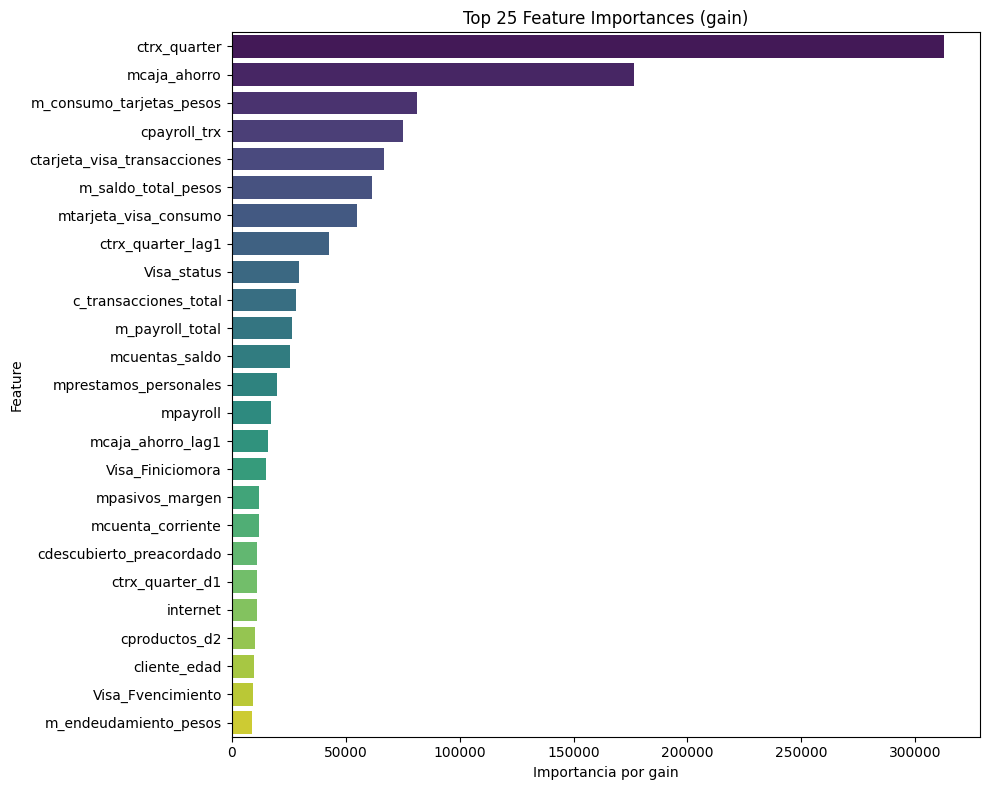

In [21]:
# =========================
# 8) Feature importance del modelo LightGBM
# =========================

feature_importance_gain = model.feature_importance(importance_type="gain")
feature_importance_split = model.feature_importance(importance_type="split")

importance_df = (
    pd.DataFrame(
        {
            "feature": feature_cols,
            "gain": feature_importance_gain,
            "split": feature_importance_split,
        }
    )
    .sort_values("gain", ascending=False)
)

print("Top 10 features por gain")
print(importance_df.head(10))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df.head(25),
    x="gain",
    y="feature",
    palette="viridis",
)
plt.title("Top 25 Feature Importances (gain)")
plt.xlabel("Importancia por gain")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [22]:
%%time
# =========================
# 9) Predicciones binarias finales y archivo submit
# =========================

models = [model]
predictions_per_seed = [apply_pd["pred_lgbm"].to_numpy()]

predictions_matrix = np.vstack(predictions_per_seed)
final_predictions = np.mean(predictions_matrix, axis=0)

clientes_ordenados = np.argsort(final_predictions)[::-1]

n_clientes_objetivo = 11000
predicciones_binarias = np.zeros(len(final_predictions), dtype=int)
predicciones_binarias[clientes_ordenados[:n_clientes_objetivo]] = 1

id_apply = apply_pd["numero_de_cliente"].to_numpy()
submit_df = pd.DataFrame(
    {
        "numero_de_cliente": id_apply[clientes_ordenados],
        "Predicted": predicciones_binarias[clientes_ordenados],
    }
)

submit_df

submit_path = BASE_DIR / "verificar_202106_submit_lgbm.csv"
submit_path.parent.mkdir(parents=True, exist_ok=True)
submit_df.to_csv(submit_path, index=False)

print("=== Submit APPLY listo ===")
print(f"Archivo: {submit_path}")
print(f"Clientes positivos: {predicciones_binarias.sum()} de {len(predicciones_binarias)}")

#clientes_valid_ordenados = np.argsort(valid_scores)[::-1]
#predicciones_binarias_valid = np.zeros(len(valid_scores), dtype=int)
#predicciones_binarias_valid[clientes_valid_ordenados[:n_clientes_objetivo]] = 1

#id_valid = test_pd["numero_de_cliente"].to_numpy()
#submit_valid_df = pl.DataFrame(
#    {
#        "numero_de_cliente": id_valid[clientes_valid_ordenados],
#        "Predicted": predicciones_binarias_valid[clientes_valid_ordenados],
#    }
#)

#submit_valid_path = BASE_DIR / "submit_lgbm_test202106.csv"
#submit_valid_df.write_csv(submit_valid_path)

#print("\n=== Submit TEST 202106 listo ===")
#print(f"Archivo: {submit_valid_path}")
#print(f"Clientes positivos: {predicciones_binarias_valid.sum()} de {len(predicciones_binarias_valid)}")

=== Submit APPLY listo ===
Archivo: /home/nicocaviglia031/dmeyf2025/Competencia 3/dmeyf2025/verificar_202106_submit_lgbm.csv
Clientes positivos: 11000 de 164596
CPU times: user 154 ms, sys: 2.9 ms, total: 157 ms
Wall time: 156 ms


In [23]:
# Filtrar los clientes con Predicted == 1
df_filtered_ensemble = submit_df[submit_df["Predicted"] == 1][["numero_de_cliente"]]
# Guardar CSV sin encabezados ni índice
df_filtered_ensemble.to_csv("Charizard777.csv", index=False, header=False)